In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

In [2]:
# Load data 
df = pd.read_csv("full_data_merged.csv", parse_dates=["date"])

STORE  = 1
FAMILY = "GROCERY I"

daily = (
    df[(df["store_nbr"] == STORE) & (df["family"] == FAMILY)]
    .copy()
    .set_index("date")
    .sort_index()
)

# Normalize columns name
daily = daily.rename(columns={
    "oil_price_lag_1": "oil_price_lag1",
    "oil_price_lag_7": "oil_price_lag7",
})

# Forward-fill oil price
daily[["oil_price", "oil_price_lag1", "oil_price_lag7"]] = (
    daily[["oil_price", "oil_price_lag1", "oil_price_lag7"]].ffill()
)

# Get sales daily
ts = daily["sales"].asfreq('D').dropna()

print(f"Store  : {STORE}  |  Family : {FAMILY}")
print(f"Date range : {ts.index.min().date()} → {ts.index.max().date()}")
print(f"Total days : {len(ts)}")

Store  : 1  |  Family : GROCERY I
Date range : 2013-01-01 → 2017-08-15
Total days : 1684


In [3]:
# ADF test
adf_result = adfuller(ts)
print(f"ADF p-value: {adf_result[1]:.4f}")
print("→", "Stationary" if adf_result[1] < 0.05 else "Non-stationary")

ADF p-value: 0.0008
→ Stationary


In [4]:
# Seasonal differencing (lag=7)
ts_seasonal_diff = ts.diff(7).dropna()

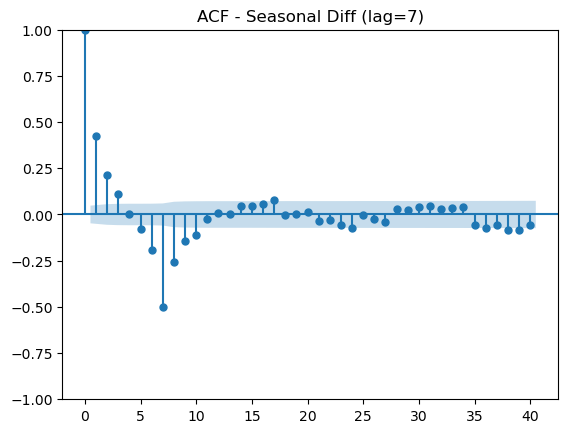

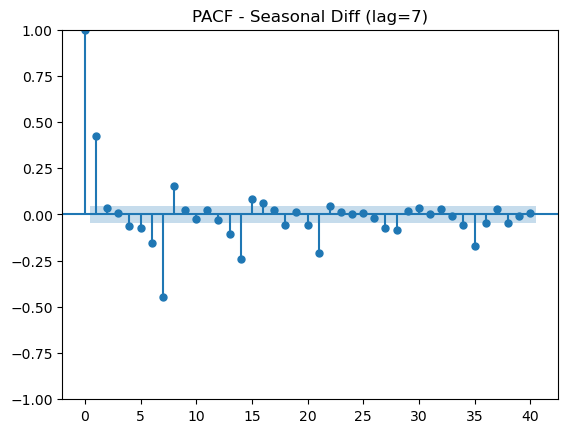

In [5]:
# ACF / PACF after seasonal diff
plot_acf(ts_seasonal_diff, lags=40)
plt.title("ACF - Seasonal Diff (lag=7)")
plt.show()

plot_pacf(ts_seasonal_diff, lags=40)
plt.title("PACF - Seasonal Diff (lag=7)")
plt.show()

In [6]:
# Train / Test split 80/20
train_size = int(len(ts) * 0.8)
train = ts[:train_size]
test  = ts[train_size:]

print(f"Train : {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)")
print(f"Test  : {test.index.min().date()}  → {test.index.max().date()}  ({len(test)} days)")

Train : 2013-01-01 → 2016-09-11  (1347 days)
Test  : 2016-09-12  → 2017-08-15  (337 days)


In [7]:
# Fit SARIMA(1,1,1)(1,1,1,7) 
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1347
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -10120.893
Date:                           Mon, 27 Apr 2026   AIC                          20251.786
Time:                                   12:55:27   BIC                          20277.750
Sample:                                        0   HQIC                         20261.517
                                          - 1347                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4290      0.011     38.481      0.000       0.407       0.451
ma.L1         -1.0000      0.013    -76.560

In [8]:
# Grid search SARIMA — fixed d=1 
p = q = range(0, 3)
P = Q = range(0, 2)

best_aic        = float("inf")
best_gs_model   = None
best_gs_params  = None

for param in itertools.product(p, q):
    for seasonal in itertools.product(P, Q):
        try:
            m_tmp = SARIMAX(
                train,
                order=(param[0], 1, param[1]),
                seasonal_order=(seasonal[0], 1, seasonal[1], 7),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)

            if m_tmp.aic < best_aic:
                best_aic       = m_tmp.aic
                best_gs_model  = m_tmp
                best_gs_params = (param, seasonal)
        except:
            continue

print("Best AIC:", round(best_aic, 2))
print("Best params (p,q) / (P,Q):", best_gs_params)

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dat

Best AIC: 20221.06
Best params (p,q) / (P,Q): ((1, 2), (0, 1))


c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


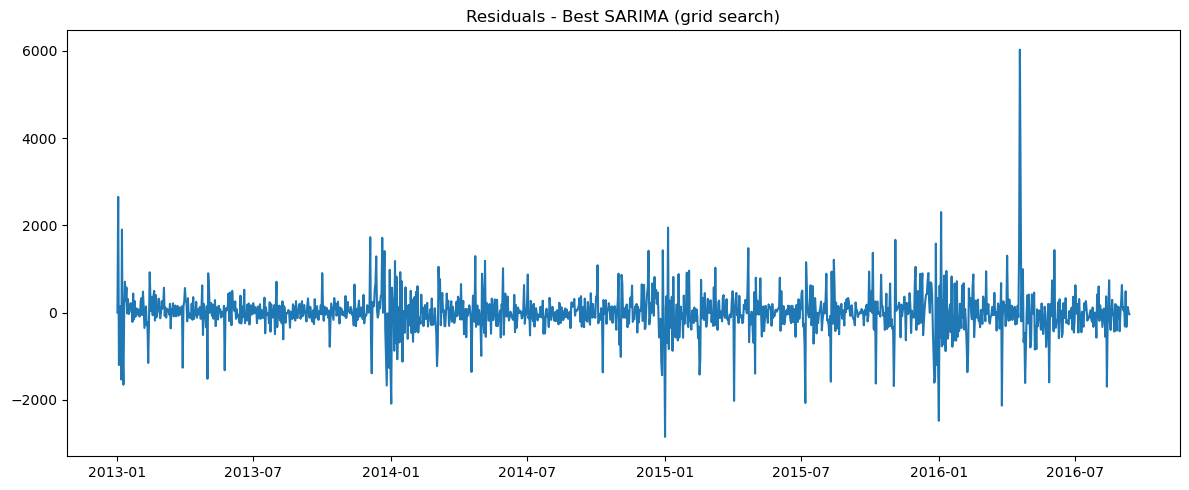

In [9]:
# Residuals of best grid search model
residuals = best_gs_model.resid

plt.figure(figsize=(12, 5))
plt.plot(residuals)
plt.title("Residuals - Best SARIMA (grid search)")
plt.tight_layout()
plt.show()

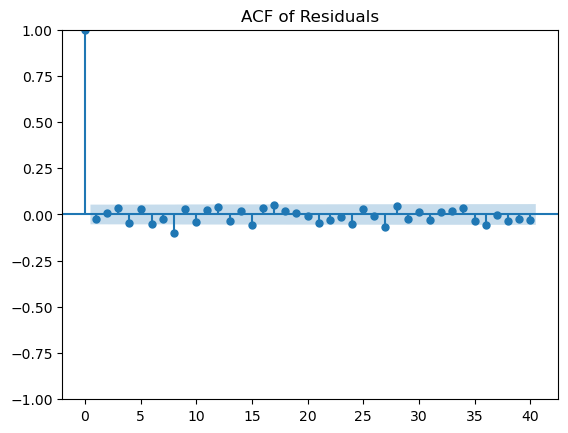

In [10]:
plot_acf(residuals.dropna(), lags=40)
plt.title("ACF of Residuals")
plt.show()

In [11]:
lb = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)
print(lb)

      lb_stat  lb_pvalue
10  27.170806   0.002447


In [12]:
# Forecast full test set 
forecast_obj = sarima_result.get_forecast(steps=len(test))
forecast     = forecast_obj.predicted_mean
forecast_ci  = forecast_obj.conf_int()
forecast.index = test.index

c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Laptop\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


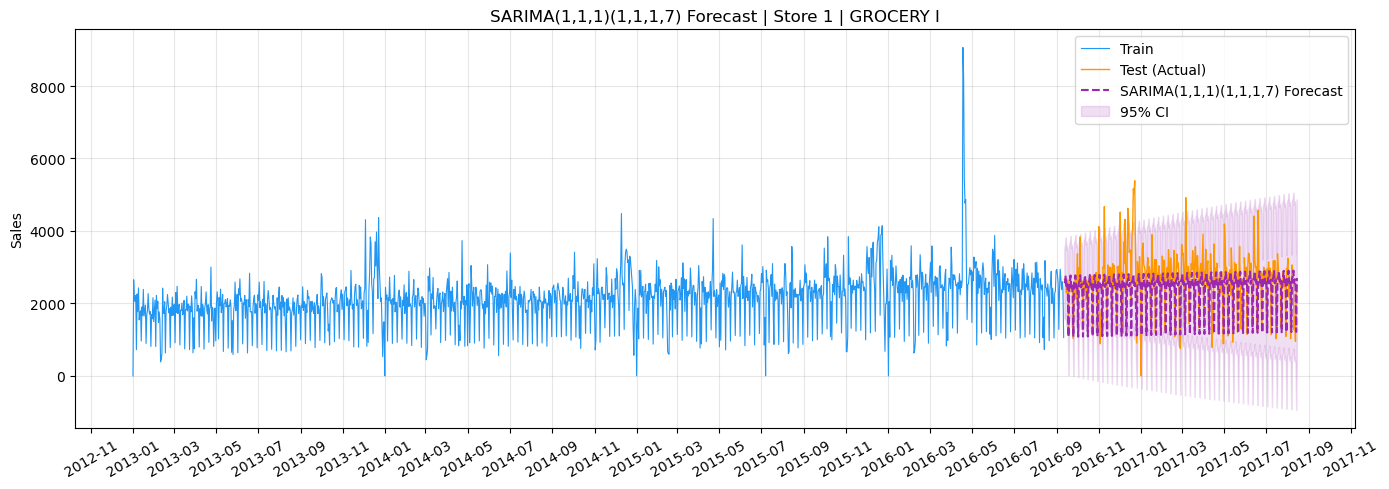

In [13]:
# Plot train / test / forecast
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train,     color="#2196F3", lw=0.8, label="Train")
ax.plot(test.index,  test,      color="#FF9800", lw=1.0, label="Test (Actual)")
ax.plot(test.index,  forecast,  color="#9C27B0", lw=1.5, ls="--",
        label="SARIMA(1,1,1)(1,1,1,7) Forecast")
ax.fill_between(test.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color="#9C27B0", alpha=0.15, label="95% CI")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.set_title(f"SARIMA(1,1,1)(1,1,1,7) Forecast | Store {STORE} | {FAMILY}")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Đánh giá metrics trên toàn test set
df_eval = pd.concat([test, forecast], axis=1).dropna()
df_eval.columns = ["actual", "forecast"]

mae  = mean_absolute_error(df_eval["actual"], df_eval["forecast"])
rmse = np.sqrt(mean_squared_error(df_eval["actual"], df_eval["forecast"]))

print(f"SARIMA(1,1,1)(1,1,1,7)")
print(f"  AIC  : {sarima_result.aic:.2f}")
print(f"  MAE  : {mae:.2f}")
print(f"  RMSE : {rmse:.2f}")

SARIMA(1,1,1)(1,1,1,7)
  AIC  : 20251.79
  MAE  : 651.54
  RMSE : 884.69
